<a href="https://colab.research.google.com/github/kamat-v/qc-course-materials/blob/main/notebooks/week10_quantum_phase_estimation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install qiskit qiskit-aer matplotlib pylatexenc --quiet

# Quantum Phase Estimation: A Practical Demonstration

## Overview

In this notebook, we'll implement Quantum Phase Estimation (QPE) and test it on three well-known quantum gates: the $S$-gate the $T$-gate and the rotation gate $R_z(2\pi/5)$.

### What is QPE?

Quantum Phase Estimation is an algorithm that takes as input:
- A unitary operator $U$
- An eigenvector $|\psi\rangle$ of $U$ (where $U|\psi\rangle = e^{2\pi i \theta}|\psi\rangle$)
- A number of phase qubits $m$ (determining the precision)

and outputs an $m$-bit approximation to the phase $\theta$.

### The QPE Guarantee

For QPE with $m$ phase qubits, if the eigenvalue phase is $\theta$, then the measurement outcome $y \in \{0, 1, \ldots, 2^m-1\}$ satisfies
$$\left|\theta - \frac{y}{2^m}\right| \leq \frac{1}{2^{m+1}}$$
with probability at least $\frac{4}{\pi^2} \approx 0.405$.

When $\theta = \frac{k}{2^m}$ for some integer $k$ (exact $m$-bit representation), QPE returns the exact answer with certainty.

### Our Test Cases

We'll test QPE on:
1. $S = \begin{pmatrix} 1 & 0 \\ 0 & i \end{pmatrix}$, with eigenvalue $i = e^{i\pi/2} = e^{2\pi i \cdot 1/4}$, so $\theta = 1/4$
2. $T = \begin{pmatrix} 1 & 0 \\ 0 & e^{i\pi/4} \end{pmatrix}$, with eigenvalue $e^{i\pi/4} = e^{2\pi i \cdot 1/8}$, so $\theta = 1/8$
3. $R_z(2\pi/5) = \begin{pmatrix} 1 & 0 \\ 0 & e^{i2\pi/5} \end{pmatrix}$, with eigenvalue $e^{2\pi i/5}$, so $\theta = 1/5$

For each of the three gates, we'll use the eigenvector $|\psi\rangle = |1\rangle$.

In [3]:
# Import necessary Qiskit libraries
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import numpy as np
import matplotlib.pyplot as plt

# For building controlled gates
from qiskit.circuit.library import QFT

## Helper Functions

We'll create helper functions to:
1. Build controlled versions of our unitary gates raised to various powers
2. Construct the full QPE circuit
3. Convert measurement outcomes to phase estimates

In [22]:
def controlled_s_power(circuit, control_qubit, target_qubit, power):
    """
    Apply controlled-S^power gate.

    S-gate: [[1, 0], [0, i]]
    S^2 = Z (since i^2 = -1)
    S^4 = I (identity)

    Args:
        circuit: QuantumCircuit to add gate to
        control_qubit: control qubit index
        target_qubit: target qubit index
        power: exponent for S gate
    """
    # Reduce power modulo 4 since S^4 = I
    power = power % 4

    if power == 0:
        # S^0 = Identity, do nothing
        pass
    elif power == 1:
        # S = Phase gate with phase pi/2
        circuit.cp(np.pi/2, control_qubit, target_qubit)
    elif power == 2:
        # S^2 = Z gate
        circuit.cz(control_qubit, target_qubit)
    elif power == 3:
        # S^3 = S^(-1) = S^dagger = Phase gate with phase -pi/2
        circuit.cp(-np.pi/2, control_qubit, target_qubit)


def controlled_t_power(circuit, control_qubit, target_qubit, power):
    """
    Apply controlled-T^power gate.

    T-gate: [[1, 0], [0, e^(i*pi/4)]]
    T^8 = I (identity)

    Args:
        circuit: QuantumCircuit to add gate to
        control_qubit: control qubit index
        target_qubit: target qubit index
        power: exponent for T gate
    """
    # Reduce power modulo 8 since T^8 = I
    power = power % 8

    if power == 0:
        # T^0 = Identity, do nothing
        pass
    else:
        # T^k has phase k*pi/4
        phase = power * np.pi / 4
        circuit.cp(phase, control_qubit, target_qubit)

def controlled_rz_power(circuit, control_qubit, target_qubit, phi, power):
    """
    Apply controlled-R_z(phi)^power gate.

    R_z(phi) = [[1, 0], [0, e^(i*phi)]]
    R_z(phi)^k has phase k*phi

    Args:
        circuit: QuantumCircuit to add gate to
        control_qubit: control qubit index
        target_qubit: target qubit index
        phi: rotation angle
        power: exponent for R_z gate
    """
    if power == 0:
        # R_z^0 = Identity, do nothing
        pass
    else:
        # R_z(phi)^k has phase k*phi
        phase = power * phi
        circuit.cp(phase, control_qubit, target_qubit)


def measurement_to_theta(measurement_string, m):
    """
    Convert binary measurement outcome to phase estimate.

    Args:
        measurement_string: binary string like '01' or '001'
        m: number of phase qubits

    Returns:
        theta: estimated phase value
    """
    # Convert binary string to integer
    y = int(measurement_string, 2)
    # Compute theta = y / 2^m
    theta = y / (2**m)
    return theta

## Building the QPE Circuit

The QPE circuit has the following structure:

1. **Initialize**: Start with $m$ phase qubits in $|0\rangle$ and one eigenstate qubit in $|\psi\rangle$
2. **Hadamard layer**: Apply $H$ to all phase qubits to create superposition
3. **Controlled-U gates**: Apply controlled-$U^{2^j}$ from phase qubit $j$ to the eigenstate qubit
4. **Inverse QFT**: Apply $\text{QFT}^\dagger$ to the phase qubits
5. **Measure**: Measure the phase qubits to extract the phase estimate

We'll create a general function that works for any unitary operator.

In [23]:
def build_qpe_circuit(m, gate_type='S', phi=None, prepare_eigenstate=True):
    """
    Build a QPE circuit for S-gate, T-gate, or R_z rotation gate.

    Args:
        m: number of phase qubits (precision)
        gate_type: 'S', 'T', or 'Rz'
        phi: rotation angle for R_z gate (required if gate_type='Rz')
        prepare_eigenstate: if True, prepare |1⟩ as eigenstate;
                           if False, leave in |0⟩ for user to prepare

    Returns:
        circuit: QuantumCircuit implementing QPE
    """
    # Create quantum registers
    # First m qubits are phase qubits (counting register)
    # Last qubit is the eigenstate
    qr_phase = QuantumRegister(m, 'phase')
    qr_eigenstate = QuantumRegister(1, 'eigenstate')
    cr = ClassicalRegister(m, 'measurement')

    circuit = QuantumCircuit(qr_phase, qr_eigenstate, cr)

    # Step 1: Prepare eigenstate |ψ⟩ = |1⟩
    if prepare_eigenstate:
        circuit.x(qr_eigenstate[0])
        circuit.barrier()

    # Step 2: Apply Hadamard gates to all phase qubits
    for j in range(m):
        circuit.h(qr_phase[j])
    circuit.barrier()

    # Step 3: Apply controlled-U^(2^j) gates
    # Qubit j (0-indexed from top) controls U^(2^j)
    for j in range(m):
        power = 2**j

        if gate_type == 'S':
            controlled_s_power(circuit, qr_phase[j], qr_eigenstate[0], power)
        elif gate_type == 'T':
            controlled_t_power(circuit, qr_phase[j], qr_eigenstate[0], power)
        elif gate_type == 'Rz':
            if phi is None:
                raise ValueError("phi must be specified for Rz gate")
            controlled_rz_power(circuit, qr_phase[j], qr_eigenstate[0], phi, power)
        else:
            raise ValueError("gate_type must be 'S', 'T', or 'Rz'")

    circuit.barrier()

    # Step 4: Apply inverse QFT to phase qubits
    # Qiskit's QFT applies to a list of qubits
    qft = QFT(num_qubits=m, inverse=True, do_swaps=True)
    circuit.compose(qft.decompose(), qubits=range(m), inplace=True)
    circuit.barrier()

    # Step 5: Measure phase qubits
    circuit.measure(qr_phase, cr)

    return circuit

## Test 1: S-Gate with m=2 Phase Qubits

### Theory

The S-gate has eigenvalue $i = e^{i\pi/2} = e^{2\pi i \cdot 1/4}$ for eigenvector $|1\rangle$.

This means $\theta = 1/4 = 0.25$.

### Expected Outcome

With $m=2$ phase qubits, QPE should measure $|01\rangle$ with **certainty** (probability 1), since:
$$\frac{y}{2^m} = \frac{1}{4} = \theta \quad \text{(exact)}$$

/tmp/ipykernel_2221/2593574985.py:49: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qft = QFT(num_qubits=m, inverse=True, do_swaps=True)


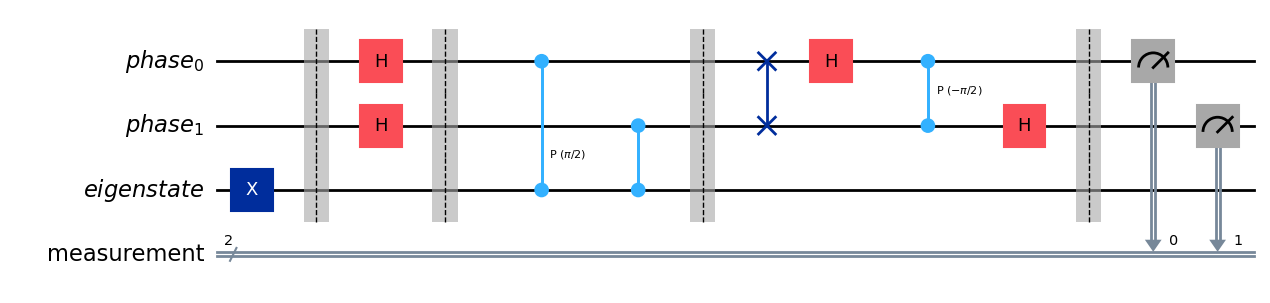

In [17]:
# Build QPE circuit for S-gate with m=2
m_s = 2
qpe_s_circuit = build_qpe_circuit(m=m_s, gate_type='S')

# Also draw with matplotlib for better visualization
qpe_s_circuit.draw(output='mpl')


Measurement results for S-gate QPE (m=2):
{'01': 1024}


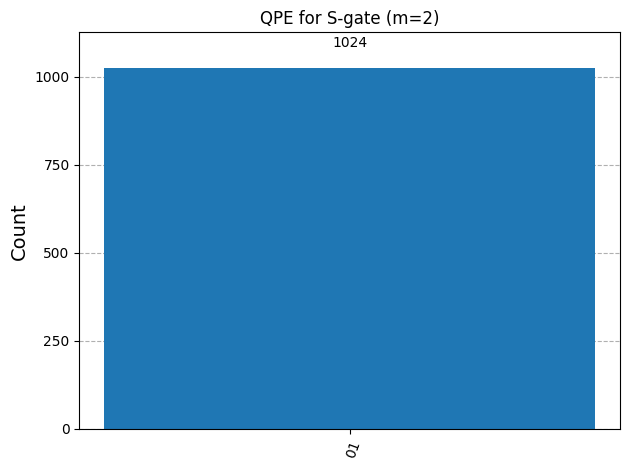

In [30]:
# Run the circuit on a simulator
simulator = AerSimulator()

# Number of shots (measurement repetitions)
shots = 1024

# Transpile and run
job_s = simulator.run(qpe_s_circuit, shots=shots)
result_s = job_s.result()
counts_s = result_s.get_counts()

print(f"\nMeasurement results for S-gate QPE (m={m_s}):")
print(counts_s)

# Plot histogram
plot_histogram(counts_s, title=f'QPE for S-gate (m={m_s})')

## Test 2: T-Gate with m=2 Phase Qubits (Insufficient Precision)

### Theory

The T-gate has eigenvalue $e^{i\pi/4} = e^{2\pi i \cdot 1/8}$ for eigenvector $|1\rangle$.

This means $\theta = 1/8 = 0.125$.

In binary: $\theta = 1/8 = 0.001_2$ (requires 3 bits for exact representation).

### What happens with only m=2?

With only 2 bits of precision, we can only represent values of the form $k/4$ for $k \in \{0,1,2,3\}$:
- $0/4 = 0.00$ (binary: $00$)
- $1/4 = 0.25$ (binary: $01$)
- $2/4 = 0.50$ (binary: $10$)
- $3/4 = 0.75$ (binary: $11$)

The true value $\theta = 1/8 = 0.125$ falls **exactly halfway** between $0/4 = 0$ and $1/4 = 0.25$.

### Expected Outcome

According to QPE theory, when $\theta$ cannot be exactly represented, the measurement outcome is **probabilistic**. Since $0.125$ is equidistant from the two nearest representable values, we expect:
- $|00\rangle$ with probability $\approx 50\%$ (estimates $\theta \approx 0$)
- $|01\rangle$ with probability $\approx 50\%$ (estimates $\theta \approx 0.25$)

This demonstrates the probabilistic nature of QPE when precision is insufficient!

/tmp/ipykernel_2221/2550785318.py:54: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qft = QFT(num_qubits=m, inverse=True, do_swaps=True)


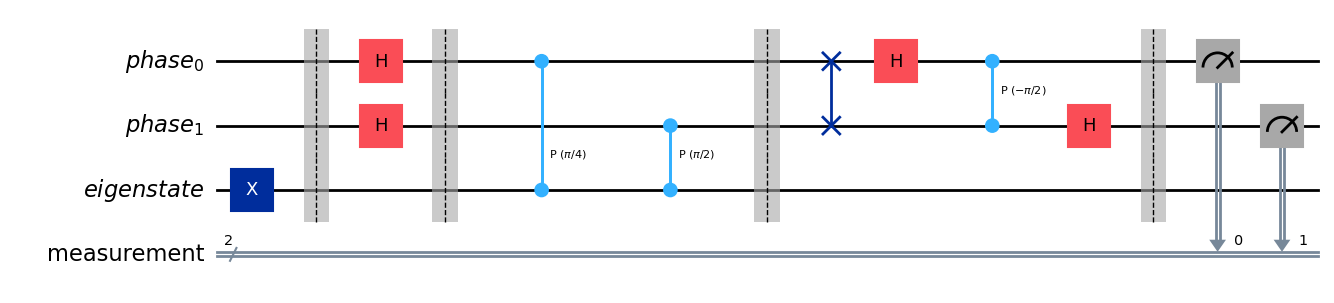

In [31]:
# Build QPE circuit for T-gate with insufficient precision (m=2)
m_t_low = 2
qpe_t_low_circuit = build_qpe_circuit(m=m_t_low, gate_type='T')

qpe_t_low_circuit.draw(output='mpl')


Measurement results for T-gate QPE with low precision (m=2):
{'11': 93, '01': 428, '10': 75, '00': 428}


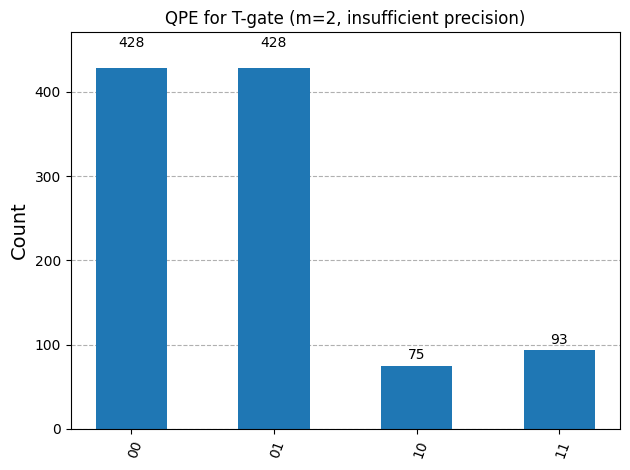

In [32]:
# Run the circuit on a simulator
job_t_low = simulator.run(qpe_t_low_circuit, shots=shots)
result_t_low = job_t_low.result()
counts_t_low = result_t_low.get_counts()

print(f"\nMeasurement results for T-gate QPE with low precision (m={m_t_low}):")
print(counts_t_low)

# Plot histogram
plot_histogram(counts_t_low, title=f'QPE for T-gate (m={m_t_low}, insufficient precision)')

## Test 3: Rotation Gate $R_z(2\pi/5)$ with m=5 Phase Qubits

### Theory

Let's test QPE on a rotation gate:
$$R_z(\phi) = \begin{pmatrix} 1 & 0 \\ 0 & e^{i\phi} \end{pmatrix}$$

For $\phi = 2\pi/5$, the eigenvalue is $e^{i \cdot 2\pi/5} = e^{2\pi i \cdot 1/5}$, so $\theta = 1/5 = 0.2$.

This is fundamentally different from our previous examples, i.e. no finite number of bits can represent this phase exactly.

### What happens with m=5?

With 5 bits, we can represent values $k/32$ for $k \in \{0, 1, \ldots, 31\}$.

The closest approximation to $1/5 = 0.2$ is:
- $6/32 = 0.1875$ (binary: $00110$)
- $7/32 = 0.21875$ (binary: $00111$)

Since $0.2$ is closer to $0.1875$ than to $0.21875$, we expect outcome $|00110\rangle$ to have the highest probability, with $|00111\rangle$ as the second most likely.

/tmp/ipykernel_2221/2550785318.py:54: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qft = QFT(num_qubits=m, inverse=True, do_swaps=True)


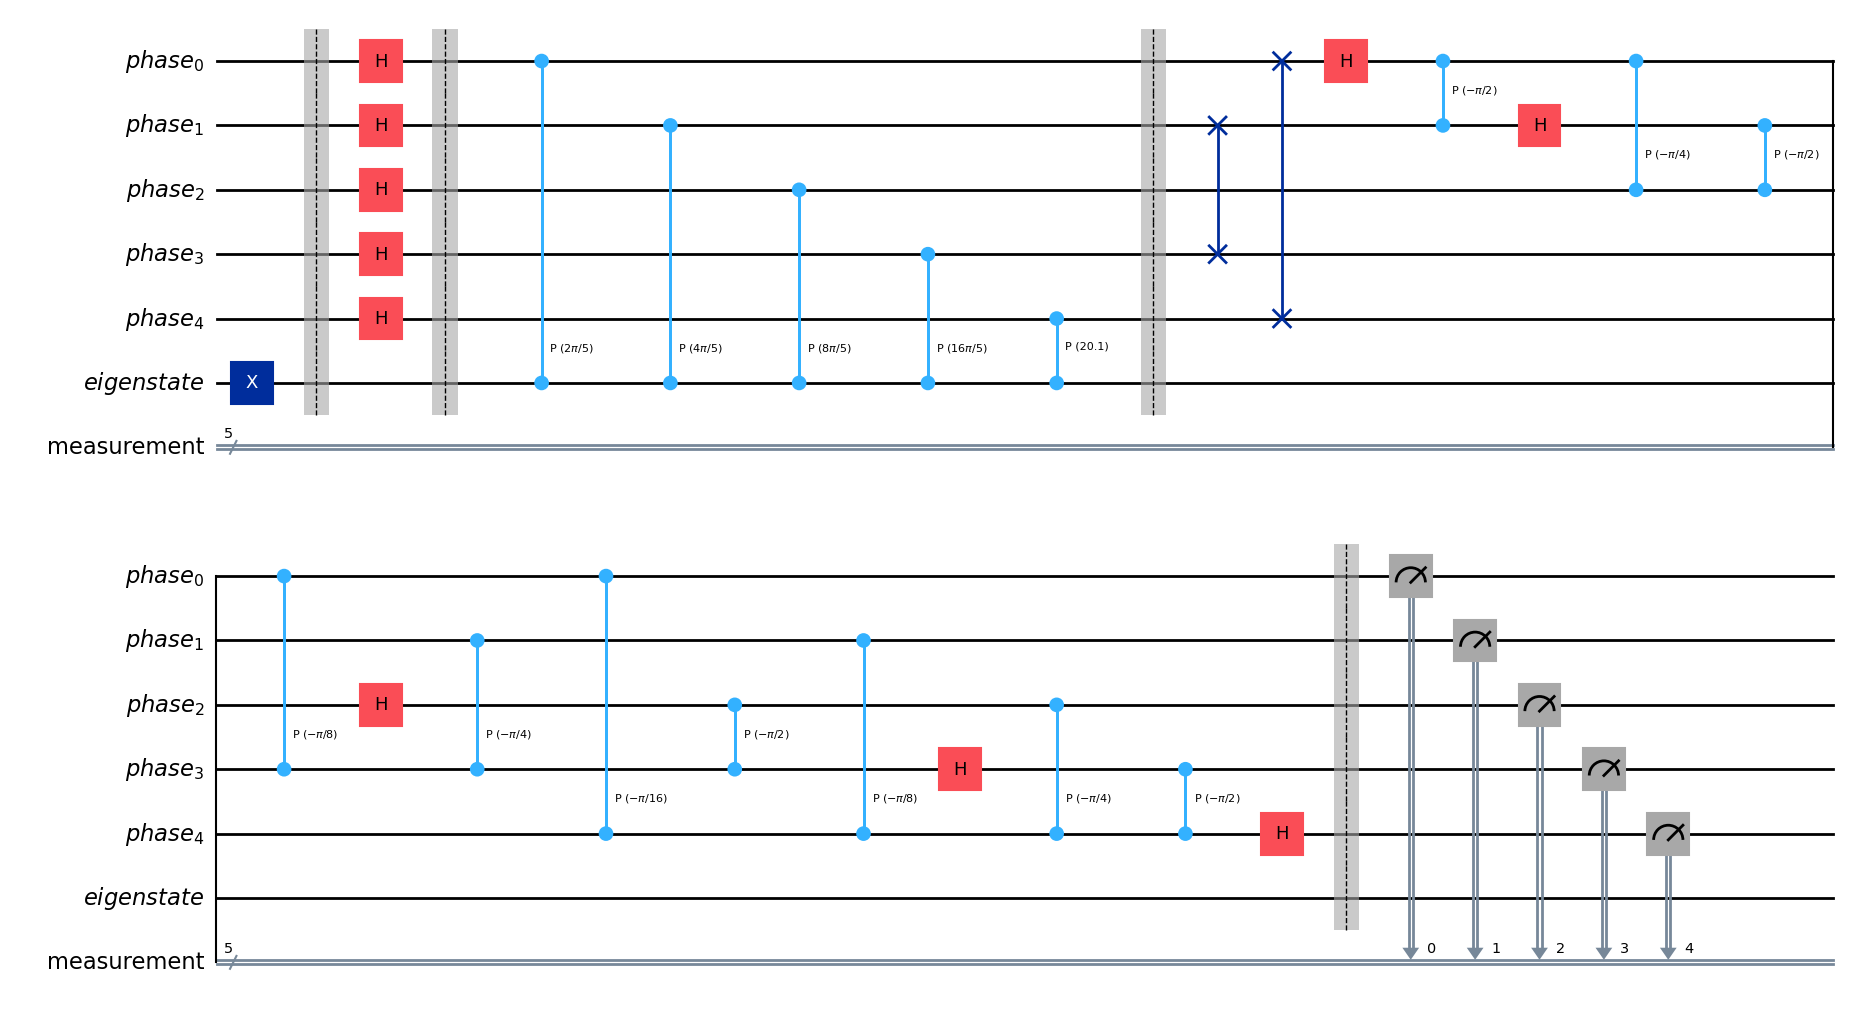

In [25]:
# Build QPE circuit for R_z(2π/5) with m=5
m_rz = 5
phi_rz = 2 * np.pi / 5  # θ = 1/5 = 0.2
qpe_rz_circuit = build_qpe_circuit(m=m_rz, gate_type='Rz', phi=phi_rz)

qpe_rz_circuit.draw(output='mpl')


Measurement results for R_z(2π/5) QPE (m=5):
{'01100': 1, '11111': 2, '01110': 2, '10110': 1, '11110': 1, '11011': 1, '10000': 1, '00011': 7, '00111': 225, '01011': 11, '10100': 1, '01101': 1, '00110': 628, '01000': 33, '01010': 10, '11010': 1, '01001': 21, '00101': 44, '00000': 2, '00010': 7, '10101': 2, '00001': 7, '10111': 1, '10010': 2, '00100': 12}


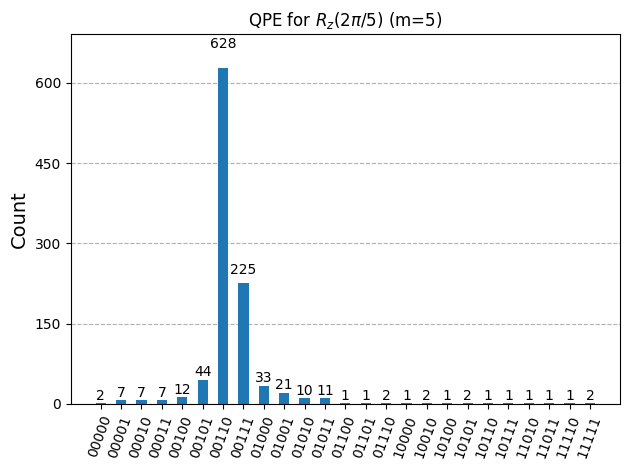

In [29]:
# Run the circuit on a simulator
job_rz = simulator.run(qpe_rz_circuit, shots=shots)
result_rz = job_rz.result()
counts_rz = result_rz.get_counts()

print(f"\nMeasurement results for R_z(2π/5) QPE (m={m_rz}):")
print(counts_rz)

plot_histogram(counts_rz, title=f'QPE for $R_z(2π/5)$ (m={m_rz})')

## Summary and Key Takeaways

Through these experiments, we've verified the theoretical guarantees of Quantum Phase Estimation and observed three distinct behaviors:

### 1. Exact Phase Representation (Test 1: S-gate, m=2)
When $\theta = k/2^m$ for some integer $k$, QPE returns the **exact answer with certainty**.
- S-gate with θ = 1/4: deterministic outcome `01`
- This is the ideal case since no approximation is needed

### 2. Insufficient Precision: $T$-gate, $m=2$
When the number of phase qubits is too small to represent θ exactly, outcomes are **probabilistic**.
- T-gate with θ = 1/8, using only m=2 bits
- roughly $40\%$ probability each concentrated on the two nearest approximations (`00` and `01`)

### 3. Arbitrary Phase Approximation: $R_z(2\pi/5)$, $m=5$
When θ has a non-terminating binary representation, QPE provides the **best m-bit approximation**.
- $\theta = \frac{1}{5} = 0.2$ cannot be represented exactly in binary
- QPE finds the closest representable values with high probability
- Error bounded by $\frac{1}{2^{m+1}}$.